In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)
from fastapi import FastAPI
import uvicorn
import pickle
import streamlit as st
import requests



In [2]:
df = pd.read_csv('Dataset(BankChurners)_CampusHiring_Dec2025(dataset).csv')
df.head()

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000


In [3]:
df.shape


(10127, 21)

In [4]:
df.columns


Index(['CLIENTNUM', 'Attrition_Flag', 'Customer_Age', 'Gender',
       'Dependent_count', 'Education_Level', 'Marital_Status',
       'Income_Category', 'Card_Category', 'Months_on_book',
       'Total_Relationship_Count', 'Months_Inactive_12_mon',
       'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal',
       'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt',
       'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio'],
      dtype='object')

In [5]:
df.dtypes


CLIENTNUM                     int64
Attrition_Flag               object
Customer_Age                  int64
Gender                       object
Dependent_count               int64
Education_Level              object
Marital_Status               object
Income_Category              object
Card_Category                object
Months_on_book                int64
Total_Relationship_Count      int64
Months_Inactive_12_mon        int64
Contacts_Count_12_mon         int64
Credit_Limit                float64
Total_Revolving_Bal           int64
Avg_Open_To_Buy             float64
Total_Amt_Chng_Q4_Q1        float64
Total_Trans_Amt               int64
Total_Trans_Ct                int64
Total_Ct_Chng_Q4_Q1         float64
Avg_Utilization_Ratio       float64
dtype: object

In [6]:
df.dtypes.value_counts()


int64      10
object      6
float64     5
dtype: int64

In [7]:
df.isnull().sum()


CLIENTNUM                   0
Attrition_Flag              0
Customer_Age                0
Gender                      0
Dependent_count             0
Education_Level             0
Marital_Status              0
Income_Category             0
Card_Category               0
Months_on_book              0
Total_Relationship_Count    0
Months_Inactive_12_mon      0
Contacts_Count_12_mon       0
Credit_Limit                0
Total_Revolving_Bal         0
Avg_Open_To_Buy             0
Total_Amt_Chng_Q4_Q1        0
Total_Trans_Amt             0
Total_Trans_Ct              0
Total_Ct_Chng_Q4_Q1         0
Avg_Utilization_Ratio       0
dtype: int64

In [8]:
df.describe()


,CLIENTNUM,Customer_Age,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
count,1.012700e+04,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000
mean,7.391776e+08,46.325960,2.346203,35.928409,3.812580,2.341167,2.455317,8631.953698,1162.814061,7469.139637,0.759941,4404.086304,64.858695,0.712222,0.274894
std,3.690378e+07,8.016814,1.298908,7.986416,1.554408,1.010622,1.106225,9088.776650,814.987335,9090.685324,0.219207,3397.129254,23.472570,0.238086,0.275691
min,7.080821e+08,26.000000,0.000000,13.000000,1.000000,0.000000,0.000000,1438.300000,0.000000,3.000000,0.000000,510.000000,10.000000,0.000000,0.000000
25%,7.130368e+08,41.000000,1.000000,31.000000,3.000000,2.000000,2.000000,2555.000000,359.000000,1324.500000,0.631000,2155.500000,45.000000,0.582000,0.023000
50%,7.179264e+08,46.000000,2.000000,36.000000,4.000000,2.000000,2.000000,4549.000000,1276.000000,3474.000000,0.736000,3899.000000,67.000000,0.702000,0.176000
75%,7.731435e+08,52.000000,3.000000,40.000000,5.000000,3.000000,3.000000,11067.500000,1784.000000,9859.000000,0.859000,4741.000000,81.000000,0.818000,0.503000
max,8.283431e+08,73.000000,5.000000,56.000000,6.000000,6.000000,6.000000,34516.000000,2517.000000,34516.000000,3.397000,18484.000000,139.000000,3.714000,0.999000


In [9]:
df['Attrition_Flag'].value_counts()


Existing Customer    8500
Attrited Customer    1627
Name: Attrition_Flag, dtype: int64

In [ ]:
#TASK 2: FEATURE ENGINEERING (STEP-BY-STEP)

In [10]:
target = "Attrition_Flag"


In [11]:
df.columns


Index(['CLIENTNUM', 'Attrition_Flag', 'Customer_Age', 'Gender',
       'Dependent_count', 'Education_Level', 'Marital_Status',
       'Income_Category', 'Card_Category', 'Months_on_book',
       'Total_Relationship_Count', 'Months_Inactive_12_mon',
       'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal',
       'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt',
       'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio'],
      dtype='object')

In [12]:
avg_credit_limit = df["Credit_Limit"].mean()

df["Credit_Level"] = df["Credit_Limit"].apply(
    lambda x: "High" if x > avg_credit_limit else "Low"
)


In [13]:
df[["Credit_Limit", "Credit_Level"]].head()


,Credit_Limit,Credit_Level
0,12691.0,High
1,8256.0,Low
2,3418.0,Low
3,3313.0,Low
4,4716.0,Low


In [14]:
group_summary = df.groupby("Attrition_Flag")["Total_Trans_Amt"].agg(
    ["mean", "count"]
)

group_summary


,mean,count
Attrition_Flag,,
Attrited Customer,3095.025814,1627
Existing Customer,4654.655882,8500


In [15]:
df.groupby("Attrition_Flag")["Total_Trans_Ct"].mean()


Attrition_Flag
Attrited Customer    44.933620
Existing Customer    68.672588
Name: Total_Trans_Ct, dtype: float64

In [16]:
high_risk_customers = df[
    (df["Months_Inactive_12_mon"] > 3) &
    (df["Total_Trans_Ct"] < 40)
]


In [17]:
high_risk_customers.shape


(135, 22)

In [ ]:
# TASK 3: PATTERN DISCOVERY

In [18]:
sns.set(style="whitegrid")


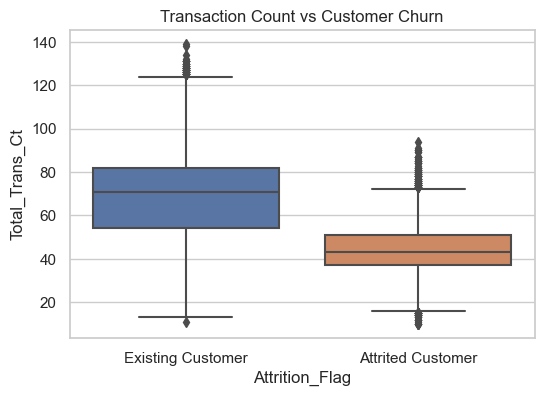

In [19]:
plt.figure(figsize=(6,4))
sns.boxplot(
    x="Attrition_Flag",
    y="Total_Trans_Ct",
    data=df
)
plt.title("Transaction Count vs Customer Churn")
plt.show()


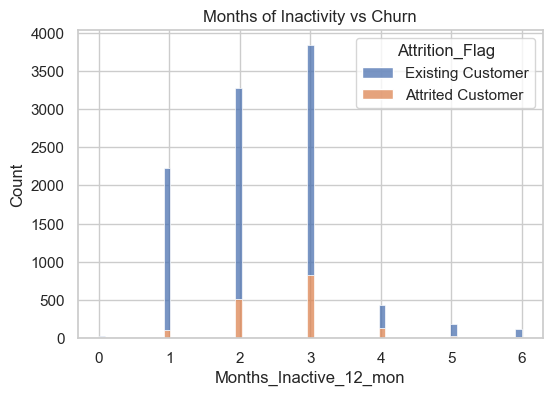

In [20]:
plt.figure(figsize=(6,4))
sns.histplot(
    data=df,
    x="Months_Inactive_12_mon",
    hue="Attrition_Flag",
    multiple="stack"
)
plt.title("Months of Inactivity vs Churn")
plt.show()


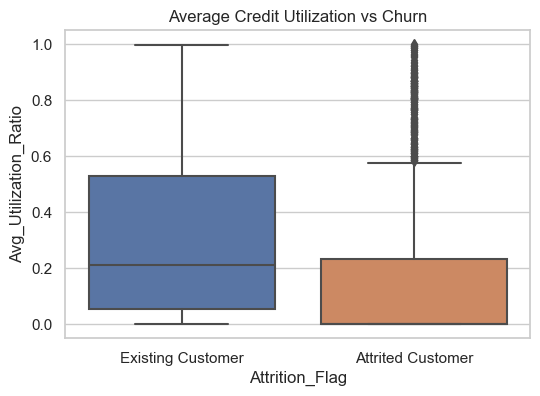

In [21]:
plt.figure(figsize=(6,4))
sns.boxplot(
    x="Attrition_Flag",
    y="Avg_Utilization_Ratio",
    data=df
)
plt.title("Average Credit Utilization vs Churn")
plt.show()


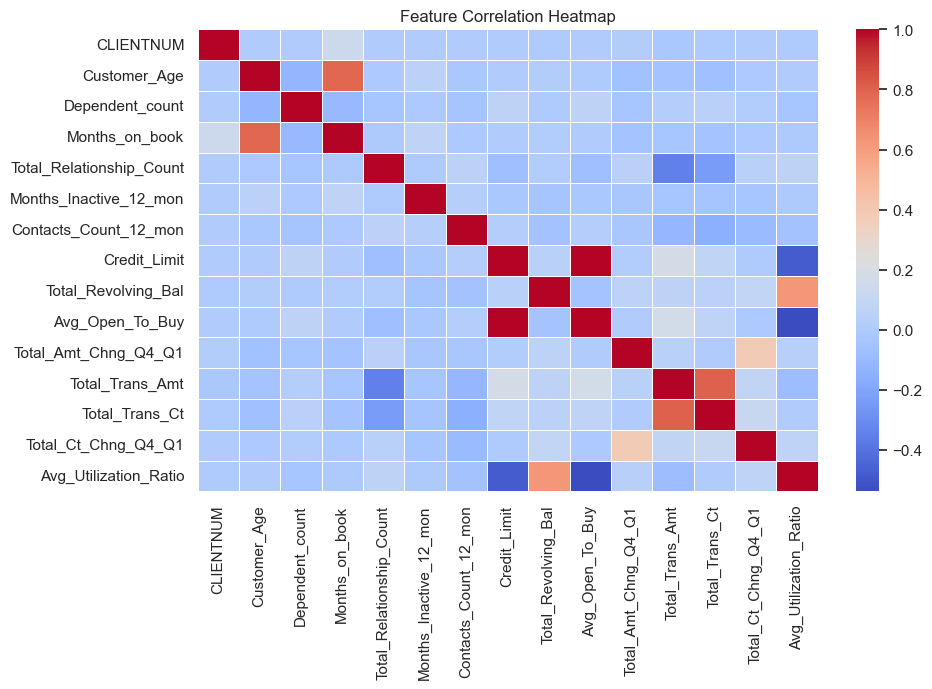

In [22]:
plt.figure(figsize=(10,6))
sns.heatmap(
    df.select_dtypes(include=["int64", "float64"]).corr(),
    cmap="coolwarm",
    linewidths=0.5
)
plt.title("Feature Correlation Heatmap")
plt.show()


In [ ]:
#TASK 4: MODEL SELECTION, DEVELOPMENT & EVALUATION

In [ ]:
#Problem Type: Binary Classification
#Objective: Predict whether a customer will churn based on demographic, financial, and behavioral features.

In [ ]:
#Chosen Model: Logistic Regression
#Logistic Regression is well-suited for binary classification problems like churn prediction.
#It is computationally efficient, interpretable, and performs well on structured tabular data.

In [23]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["Attrition_Flag_Encoded"] = le.fit_transform(df["Attrition_Flag"])


In [25]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["Attrition_Flag_Encoded"] = le.fit_transform(df["Attrition_Flag"])


In [26]:
df[["Attrition_Flag", "Attrition_Flag_Encoded"]].head()


,Attrition_Flag,Attrition_Flag_Encoded
0,Existing Customer,1
1,Existing Customer,1
2,Existing Customer,1
3,Existing Customer,1
4,Existing Customer,1


In [27]:
selected_features = [
    "Credit_Limit",
    "Total_Trans_Amt",
    "Total_Trans_Ct",
    "Months_Inactive_12_mon",
    "Avg_Utilization_Ratio"
]

X = df[selected_features]
y = df["Attrition_Flag_Encoded"]


In [28]:
print(X.columns.tolist())


['Credit_Limit', 'Total_Trans_Amt', 'Total_Trans_Ct', 'Months_Inactive_12_mon', 'Avg_Utilization_Ratio']


In [29]:
X = X.drop(columns=["Attrition_Flag_Encoded"], errors="ignore")


In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [31]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)


LogisticRegression(max_iter=1000)

In [32]:
y_pred = model.predict(X_test)


In [33]:

accuracy = accuracy_score(y_test, y_pred)
accuracy


0.8297137216189536

In [34]:
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.41      0.14      0.21       325
           1       0.85      0.96      0.90      1701

    accuracy                           0.83      2026
   macro avg       0.63      0.55      0.56      2026
weighted avg       0.78      0.83      0.79      2026



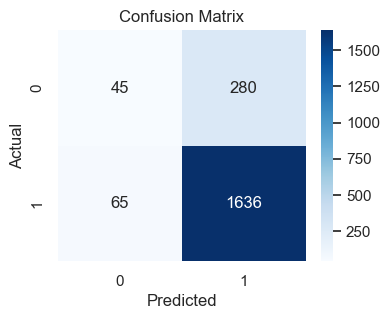

In [35]:


cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [36]:
with open("churn_model.pkl", "wb") as file:
    pickle.dump(model, file)
